# 05 - Reporte de calidad, visualización y conclusiones

Este notebook consolida la evidencia final del pipeline ETL Lakehouse. Usa las tablas cargadas en SQLite y las salidas generadas en las capas `audit`, `quarantine`, `silver` y `gold` para demostrar carga correcta, calidad de datos, trazabilidad, hallazgos y conclusiones.

El objetivo no es reprocesar los 43+ millones de viajes, sino consultar agregados y tablas finales ya persistidas.

## 1. Configuración del reporte

Se cargan librerías, rutas del proyecto y conexión a la base SQLite generada en la Fase 07.

In [1]:
from pathlib import Path
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except Exception:
    plt.style.use('default')

pd.set_option('display.max_columns', 80)
pd.set_option('display.float_format', lambda value: f'{value:,.2f}')

BASE_PATH = Path.cwd().parent if Path.cwd().name.lower() == 'notebooks' else Path.cwd()
DB_PATH = BASE_PATH / 'data' / 'database' / 'etl_taxi_gold.db'
AUDIT_PATH = BASE_PATH / 'data' / 'audit'
QUARANTINE_PATH = BASE_PATH / 'data' / 'quarantine'
GOLD_PATH = BASE_PATH / 'data' / 'gold'

if not DB_PATH.exists():
    raise FileNotFoundError(f'No se encontró la base SQLite: {DB_PATH}')

conn = sqlite3.connect(DB_PATH)
print('Base del proyecto:', BASE_PATH)
print('Base SQLite:', DB_PATH)
print('Tamaño SQLite GB:', round(DB_PATH.stat().st_size / (1024 ** 3), 2))

Matplotlib is building the font cache; this may take a moment.


Base del proyecto: c:\Users\Usuario\Downloads\etl_spark_parquet_advanced\etl_spark_parquet_advanced
Base SQLite: c:\Users\Usuario\Downloads\etl_spark_parquet_advanced\etl_spark_parquet_advanced\data\database\etl_taxi_gold.db
Tamaño SQLite GB: 9.11


In [2]:
def sql(query, params=None):
    return pd.read_sql_query(query, conn, params=params)


def show_df(title, df):
    display(Markdown(f'### {title}'))
    display(df)


def add_bar_labels(ax, values, fmt='{:.0f}'):
    for index, value in enumerate(values):
        ax.text(index, value, fmt.format(value), ha='center', va='bottom', fontsize=9)


def latest_folder(base_path, prefix):
    base_path = Path(base_path)
    candidates = [path for path in base_path.glob(f'{prefix}*') if path.is_dir()]
    if not candidates:
        return None
    return max(candidates, key=lambda path: path.stat().st_mtime)

print('Utilidades del reporte listas.')

Utilidades del reporte listas.


## 2. Evidencia de tablas cargadas

Se valida que las tablas obligatorias existan y tengan registros. Esta sección demuestra que la Fase 07 dejó los resultados disponibles para consulta SQL.

In [3]:
tables_df = sql("SELECT name FROM sqlite_master WHERE type = 'table' ORDER BY name;")
counts = []
for table_name in tables_df['name']:
    total_rows = sql(f'SELECT COUNT(*) AS total_rows FROM [{table_name}];')['total_rows'].iloc[0]
    counts.append({'table_name': table_name, 'total_rows': total_rows})

table_counts = pd.DataFrame(counts).sort_values('table_name')
show_df('Tablas disponibles en SQLite', table_counts)

### Tablas disponibles en SQLite

,table_name,total_rows
0,audit_database_load,6
1,audit_file_inventory,16
2,gold_daily_revenue,331
3,gold_location_performance,108322
4,gold_trips_clean,43890529
5,quality_metrics_summary,11
6,quality_rejected_records,631


In [4]:
required_tables = {
    'audit_file_inventory',
    'gold_trips_clean',
    'gold_daily_revenue',
    'gold_location_performance',
    'quality_rejected_records',
    'quality_metrics_summary'
}

available_tables = set(table_counts['table_name'])
missing_tables = sorted(required_tables - available_tables)

if missing_tables:
    raise AssertionError('Faltan tablas obligatorias: ' + ', '.join(missing_tables))

print('Validación correcta: todas las tablas obligatorias del PDF están cargadas en SQLite.')

Validación correcta: todas las tablas obligatorias del PDF están cargadas en SQLite.


## 3. Resumen ejecutivo

Los indicadores siguientes resumen volumen procesado, ingresos, calidad, rechazos y auditoría técnica.

In [5]:
revenue_by_service = sql('''
SELECT
    service_type,
    COUNT(*) AS total_trips,
    ROUND(SUM(total_amount), 2) AS total_revenue,
    ROUND(AVG(total_amount), 2) AS avg_ticket
FROM gold_trips_clean
GROUP BY service_type
ORDER BY total_revenue DESC;
''')

quality_totals = sql('''
SELECT
    SUM(total_records) AS total_records,
    SUM(valid_records) AS valid_records,
    SUM(rejected_records) AS rejected_records,
    SUM(duplicate_records) AS duplicate_records,
    SUM(null_critical_records) AS null_critical_records,
    SUM(suspicious_records) AS suspicious_records,
    ROUND(AVG(quality_percentage), 2) AS avg_quality_percentage
FROM quality_metrics_summary;
''')

audit_totals = sql('''
SELECT
    COUNT(*) AS audited_files,
    SUM(CASE WHEN read_status = 'READ_OK' THEN 1 ELSE 0 END) AS read_ok_files,
    SUM(CASE WHEN read_status <> 'READ_OK' THEN 1 ELSE 0 END) AS read_error_files,
    COUNT(DISTINCT schema_hash) AS distinct_schema_hashes
FROM audit_file_inventory;
''')

kpis = pd.DataFrame([
    {'indicator': 'Viajes limpios en Gold', 'value': int(revenue_by_service['total_trips'].sum())},
    {'indicator': 'Ingresos Gold USD', 'value': round(float(revenue_by_service['total_revenue'].sum()), 2)},
    {'indicator': 'Servicios procesados', 'value': int(revenue_by_service['service_type'].nunique())},
    {'indicator': 'Registros evaluados en calidad', 'value': int(quality_totals['total_records'].iloc[0])},
    {'indicator': 'Registros rechazados únicos', 'value': int(quality_totals['rejected_records'].iloc[0])},
    {'indicator': 'Calidad promedio %', 'value': float(quality_totals['avg_quality_percentage'].iloc[0])},
    {'indicator': 'Archivos auditados', 'value': int(audit_totals['audited_files'].iloc[0])},
    {'indicator': 'Archivos con error de lectura', 'value': int(audit_totals['read_error_files'].iloc[0])},
    {'indicator': 'Hashes de esquema distintos', 'value': int(audit_totals['distinct_schema_hashes'].iloc[0])}
])

show_df('Indicadores principales del pipeline', kpis)

### Indicadores principales del pipeline

,indicator,value
0,Viajes limpios en Gold,"43,890,529.00"
1,Ingresos Gold USD,"1,041,659,042.37"
2,Servicios procesados,3.00
3,Registros evaluados en calidad,"43,891,160.00"
4,Registros rechazados únicos,631.00
5,Calidad promedio %,100.00
6,Archivos auditados,16.00
7,Archivos con error de lectura,3.00
8,Hashes de esquema distintos,8.00


## 4. Consultas SQL obligatorias

Estas son las consultas pedidas por el caso de estudio para demostrar que los datos quedaron cargados y listos para análisis.

In [6]:
query_1 = sql('''
SELECT
    service_type,
    COUNT(*) AS total_trips,
    ROUND(SUM(total_amount), 2) AS total_revenue
FROM gold_trips_clean
GROUP BY service_type
ORDER BY total_revenue DESC;
''')

query_2 = sql('''
SELECT
    service_type,
    year,
    month,
    total_records,
    valid_records,
    rejected_records,
    quality_percentage
FROM quality_metrics_summary
ORDER BY year, month, service_type;
''')

query_3 = sql('''
SELECT
    pickup_location_id,
    dropoff_location_id,
    COUNT(*) AS total_trips,
    ROUND(SUM(total_amount), 2) AS total_revenue,
    ROUND(AVG(trip_duration_minutes), 2) AS avg_duration
FROM gold_trips_clean
GROUP BY pickup_location_id, dropoff_location_id
ORDER BY total_revenue DESC
LIMIT 20;
''')

show_df('Consulta 1 - Ingresos por servicio', query_1)
show_df('Consulta 2 - Métricas de calidad por servicio, año y mes', query_2)
show_df('Consulta 3 - Rutas con mayor recaudación', query_3)

### Consulta 1 - Ingresos por servicio

,service_type,total_trips,total_revenue
0,yellow,25311957,"587,819,504.35"
1,fhvhv,18452960,"451,103,000.09"
2,green,125612,"2,736,537.93"


### Consulta 2 - Métricas de calidad por servicio, año y mes

,service_type,year,month,total_records,valid_records,rejected_records,quality_percentage
0,yellow,2020,1,6281130,6280948,182,100.00
1,yellow,2021,1,1331340,1331320,20,100.00
2,yellow,2022,1,2411789,2411744,45,100.00
3,yellow,2022,2,2920554,2920496,58,100.00
4,fhvhv,2023,1,18452962,18452960,2,100.00
5,green,2023,1,64255,64252,3,100.00
6,yellow,2023,1,2991419,2991377,42,100.00
7,green,2023,2,61381,61360,21,99.97
8,yellow,2023,2,2843569,2843510,59,100.00
9,yellow,2023,3,3319914,3319805,109,100.00


### Consulta 3 - Rutas con mayor recaudación

,pickup_location_id,dropoff_location_id,total_trips,total_revenue,avg_duration
0,132,265,99509,"10,553,499.00",46.16
1,138,265,44562,"4,598,039.27",43.38
2,132,230,47241,"3,980,920.63",51.47
3,264,264,133421,"3,195,404.82",14.40
4,138,230,49638,"3,126,321.76",34.88
5,132,48,32090,"2,627,154.04",51.64
6,237,236,193528,"2,593,028.91",6.92
7,230,138,38544,"2,344,687.79",32.03
8,236,237,166680,"2,331,981.82",8.09
9,132,164,26532,"2,205,818.31",42.96


## 5. Visualización de resultados de negocio

Los siguientes gráficos resumen ingresos, volumen de viajes y evolución diaria de la capa Gold.

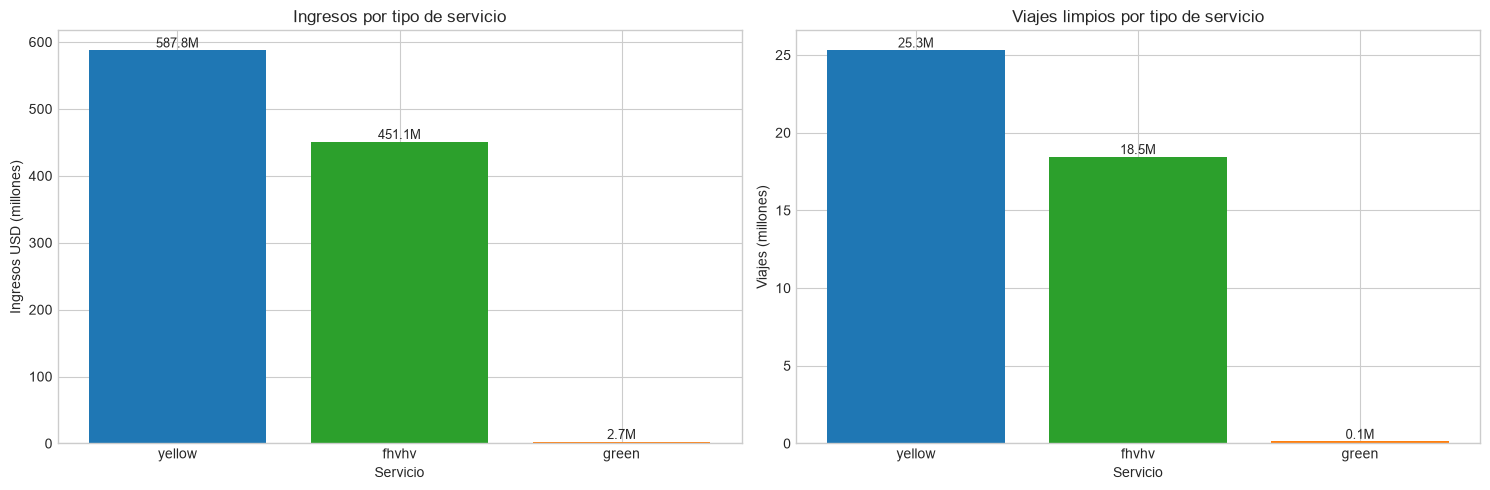

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
colors = ['#1f77b4', '#2ca02c', '#ff7f0e', '#9467bd']

axes[0].bar(revenue_by_service['service_type'], revenue_by_service['total_revenue'] / 1_000_000, color=colors[:len(revenue_by_service)])
axes[0].set_title('Ingresos por tipo de servicio')
axes[0].set_ylabel('Ingresos USD (millones)')
axes[0].set_xlabel('Servicio')
add_bar_labels(axes[0], revenue_by_service['total_revenue'] / 1_000_000, fmt='{:.1f}M')

axes[1].bar(revenue_by_service['service_type'], revenue_by_service['total_trips'] / 1_000_000, color=colors[:len(revenue_by_service)])
axes[1].set_title('Viajes limpios por tipo de servicio')
axes[1].set_ylabel('Viajes (millones)')
axes[1].set_xlabel('Servicio')
add_bar_labels(axes[1], revenue_by_service['total_trips'] / 1_000_000, fmt='{:.1f}M')

plt.tight_layout()
plt.show()

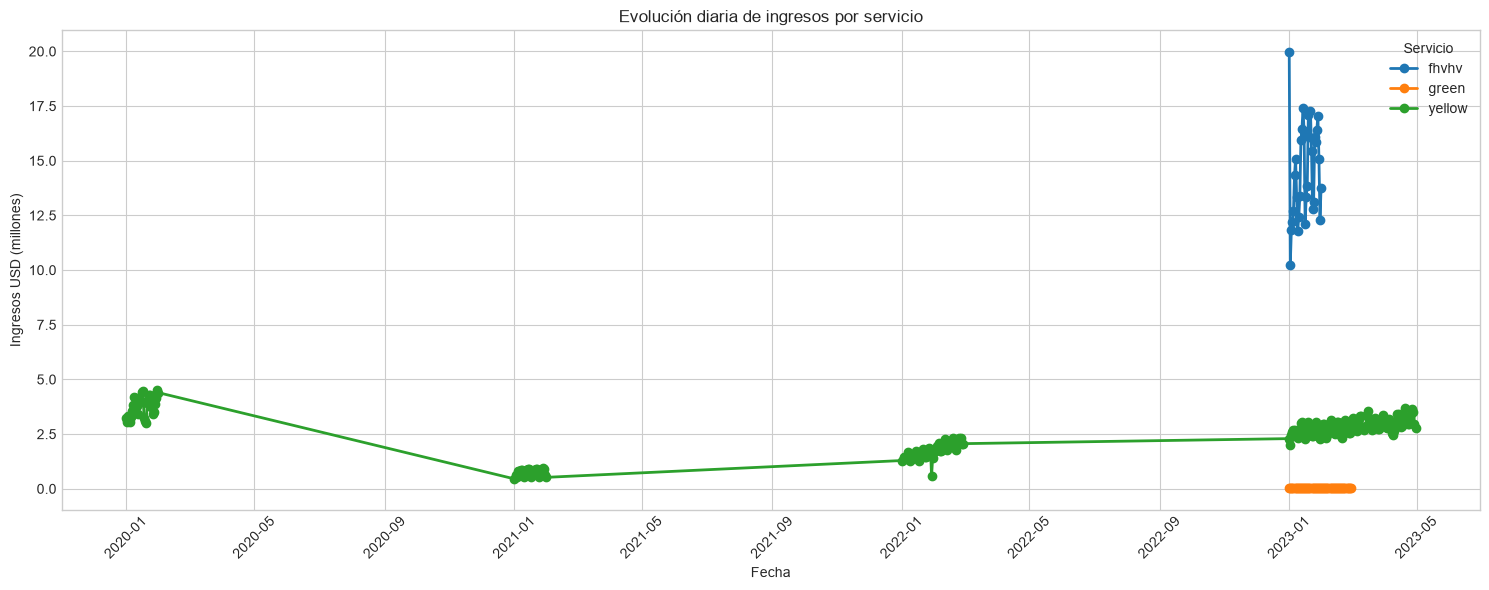

### Muestra de gold_daily_revenue

,service_type,trip_date,total_trips,total_revenue,average_fare,average_trip_distance,average_trip_duration,rejected_records,quality_percentage
0,yellow,2020-01-01,165918,"3,245,455.41",13.76,3.54,12.58,182,100.00
1,yellow,2020-01-02,159059,"3,075,201.83",13.40,3.32,13.16,182,100.00
2,yellow,2020-01-03,180342,"3,318,591.57",12.55,3.01,12.79,182,100.00
3,yellow,2020-01-04,179808,"3,200,818.81",12.24,2.97,12.07,182,100.00
4,yellow,2020-01-05,161375,"3,042,921.95",13.08,3.34,11.93,182,100.00
5,yellow,2020-01-06,174170,"3,272,336.35",12.74,3.08,12.94,182,100.00
6,yellow,2020-01-07,195837,"3,554,763.31",12.18,2.85,12.65,182,100.00
7,yellow,2020-01-08,211399,"3,826,080.85",12.10,2.79,12.79,182,100.00
8,yellow,2020-01-09,225826,"4,179,942.48",12.42,2.80,13.61,182,100.00
9,yellow,2020-01-10,222062,"4,161,739.22",12.62,2.88,13.78,182,100.00


In [8]:
daily_revenue = sql('''
SELECT
    service_type,
    trip_date,
    total_trips,
    total_revenue,
    average_fare,
    average_trip_distance,
    average_trip_duration,
    rejected_records,
    quality_percentage
FROM gold_daily_revenue
ORDER BY trip_date, service_type;
''')

daily_revenue['trip_date'] = pd.to_datetime(daily_revenue['trip_date'])

fig, ax = plt.subplots(figsize=(15, 6))
for service, data in daily_revenue.groupby('service_type'):
    ax.plot(data['trip_date'], data['total_revenue'] / 1_000_000, marker='o', linewidth=2, label=service)

ax.set_title('Evolución diaria de ingresos por servicio')
ax.set_xlabel('Fecha')
ax.set_ylabel('Ingresos USD (millones)')
ax.legend(title='Servicio')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

show_df('Muestra de gold_daily_revenue', daily_revenue.head(15))

## 6. Calidad de datos

Esta sección muestra el porcentaje de calidad por periodo, la distribución de registros válidos/rechazados y las reglas que más rechazos generaron.

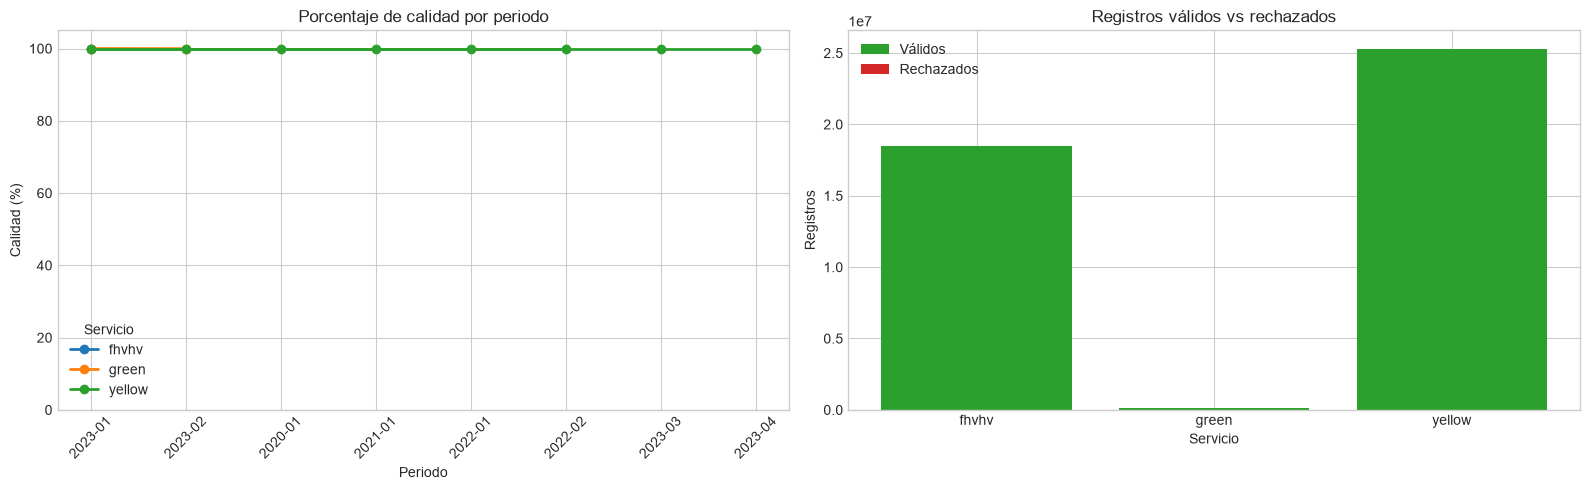

### quality_metrics_summary

,service_type,year,month,total_records,valid_records,rejected_records,duplicate_records,null_critical_records,suspicious_records,quality_percentage,period
0,yellow,2020,1,6281130,6280948,182,0,0,0,100.00,2020-01
1,yellow,2021,1,1331340,1331320,20,0,0,0,100.00,2021-01
2,yellow,2022,1,2411789,2411744,45,0,0,0,100.00,2022-01
3,yellow,2022,2,2920554,2920496,58,0,0,0,100.00,2022-02
4,fhvhv,2023,1,18452962,18452960,2,0,0,0,100.00,2023-01
5,green,2023,1,64255,64252,3,0,0,0,100.00,2023-01
6,yellow,2023,1,2991419,2991377,42,0,0,0,100.00,2023-01
7,green,2023,2,61381,61360,21,0,0,0,99.97,2023-02
8,yellow,2023,2,2843569,2843510,59,0,0,0,100.00,2023-02
9,yellow,2023,3,3319914,3319805,109,0,0,0,100.00,2023-03


In [9]:
quality_metrics = sql('''
SELECT
    service_type,
    year,
    month,
    total_records,
    valid_records,
    rejected_records,
    duplicate_records,
    null_critical_records,
    suspicious_records,
    quality_percentage
FROM quality_metrics_summary
ORDER BY year, month, service_type;
''')
quality_metrics['period'] = quality_metrics['year'].astype(str) + '-' + quality_metrics['month'].astype(str).str.zfill(2)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for service, data in quality_metrics.groupby('service_type'):
    axes[0].plot(data['period'], data['quality_percentage'], marker='o', linewidth=2, label=service)
axes[0].set_title('Porcentaje de calidad por periodo')
axes[0].set_xlabel('Periodo')
axes[0].set_ylabel('Calidad (%)')
axes[0].set_ylim(0, 105)
axes[0].legend(title='Servicio')
axes[0].tick_params(axis='x', rotation=45)

summary_by_service = quality_metrics.groupby('service_type', as_index=False)[['valid_records', 'rejected_records']].sum()
axes[1].bar(summary_by_service['service_type'], summary_by_service['valid_records'], label='Válidos', color='#2ca02c')
axes[1].bar(summary_by_service['service_type'], summary_by_service['rejected_records'], bottom=summary_by_service['valid_records'], label='Rechazados', color='#d62728')
axes[1].set_title('Registros válidos vs rechazados')
axes[1].set_xlabel('Servicio')
axes[1].set_ylabel('Registros')
axes[1].legend()

plt.tight_layout()
plt.show()

show_df('quality_metrics_summary', quality_metrics)

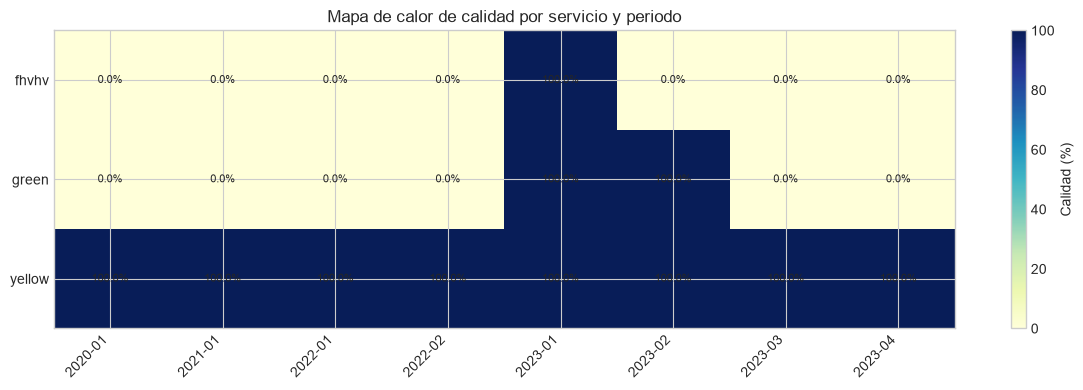

In [10]:
quality_matrix = quality_metrics.pivot_table(
    index='service_type',
    columns='period',
    values='quality_percentage',
    aggfunc='mean'
).fillna(0)

fig, ax = plt.subplots(figsize=(12, 4))
image = ax.imshow(quality_matrix.values, aspect='auto', cmap='YlGnBu', vmin=0, vmax=100)
ax.set_title('Mapa de calor de calidad por servicio y periodo')
ax.set_xticks(range(len(quality_matrix.columns)))
ax.set_xticklabels(quality_matrix.columns, rotation=45, ha='right')
ax.set_yticks(range(len(quality_matrix.index)))
ax.set_yticklabels(quality_matrix.index)

for row_idx in range(quality_matrix.shape[0]):
    for col_idx in range(quality_matrix.shape[1]):
        value = quality_matrix.iloc[row_idx, col_idx]
        ax.text(col_idx, row_idx, f'{value:.1f}%', ha='center', va='center', fontsize=8)

fig.colorbar(image, ax=ax, label='Calidad (%)')
plt.tight_layout()
plt.show()

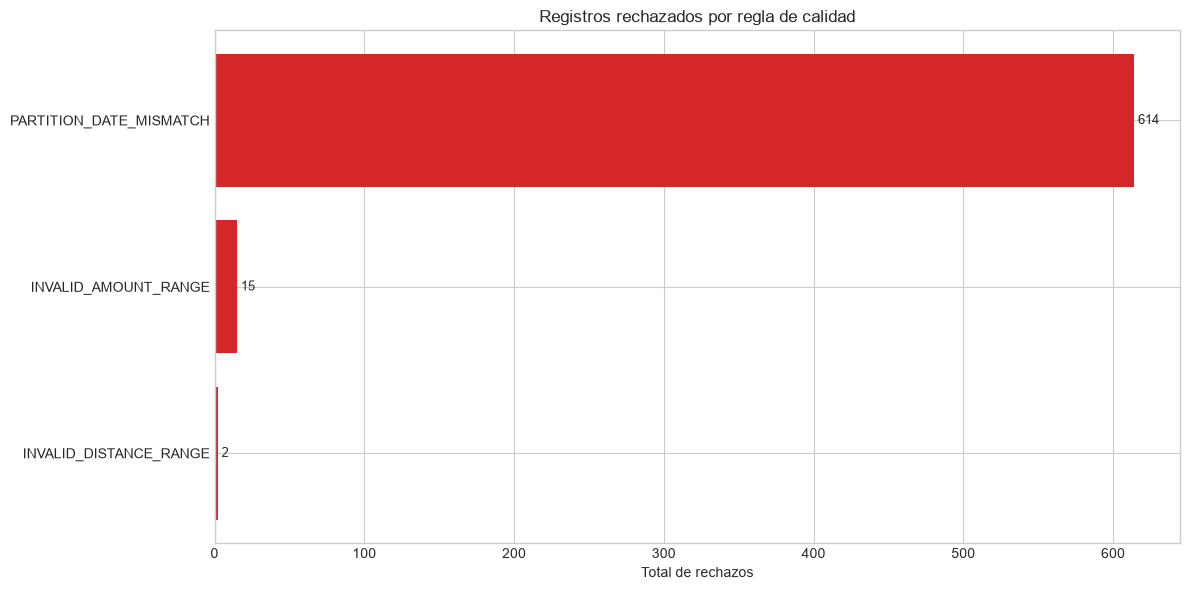

### Detalle de rechazos por regla

,rejection_rule,total_rejections
0,PARTITION_DATE_MISMATCH,614
1,INVALID_AMOUNT_RANGE,15
2,INVALID_DISTANCE_RANGE,2


In [11]:
rejections_by_rule = sql('''
SELECT
    rejection_rule,
    COUNT(*) AS total_rejections
FROM quality_rejected_records
GROUP BY rejection_rule
ORDER BY total_rejections DESC;
''')

fig, ax = plt.subplots(figsize=(12, 6))
plot_df = rejections_by_rule.sort_values('total_rejections')
ax.barh(plot_df['rejection_rule'], plot_df['total_rejections'], color='#d62728')
ax.set_title('Registros rechazados por regla de calidad')
ax.set_xlabel('Total de rechazos')
for index, value in enumerate(plot_df['total_rejections']):
    ax.text(value, index, f' {value}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

show_df('Detalle de rechazos por regla', rejections_by_rule)

## 7. Auditoría técnica y cuarentena

El pipeline no ignora archivos problemáticos. Los clasifica, registra errores y mantiene trazabilidad en `audit_file_inventory` y tablas de cuarentena.

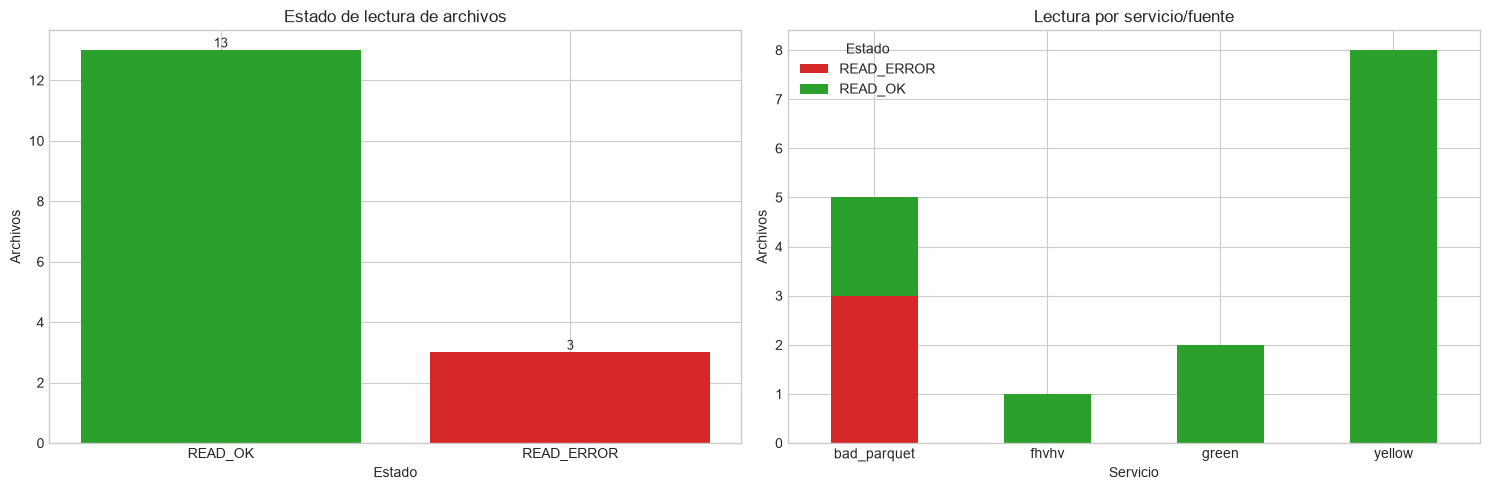

### Inventario técnico por servicio y estado

,service_type,read_status,total_files
0,bad_parquet,READ_ERROR,3
1,bad_parquet,READ_OK,2
2,fhvhv,READ_OK,1
3,green,READ_OK,2
4,yellow,READ_OK,8


In [12]:
inventory_status = sql('''
SELECT
    read_status,
    COUNT(*) AS total_files
FROM audit_file_inventory
GROUP BY read_status
ORDER BY total_files DESC;
''')

inventory_by_service = sql('''
SELECT
    service_type,
    read_status,
    COUNT(*) AS total_files
FROM audit_file_inventory
GROUP BY service_type, read_status
ORDER BY service_type, read_status;
''')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].bar(inventory_status['read_status'], inventory_status['total_files'], color=['#2ca02c', '#d62728', '#ff7f0e'])
axes[0].set_title('Estado de lectura de archivos')
axes[0].set_xlabel('Estado')
axes[0].set_ylabel('Archivos')
add_bar_labels(axes[0], inventory_status['total_files'], fmt='{:.0f}')

pivot_inventory = inventory_by_service.pivot_table(index='service_type', columns='read_status', values='total_files', fill_value=0)
pivot_inventory.plot(kind='bar', stacked=True, ax=axes[1], color=['#d62728', '#2ca02c'])
axes[1].set_title('Lectura por servicio/fuente')
axes[1].set_xlabel('Servicio')
axes[1].set_ylabel('Archivos')
axes[1].legend(title='Estado')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

show_df('Inventario técnico por servicio y estado', inventory_by_service)

In [13]:
quarantine_summary = sql('''
SELECT
    rejection_stage,
    rejection_rule,
    COUNT(*) AS total_records
FROM quality_rejected_records
GROUP BY rejection_stage, rejection_rule
ORDER BY total_records DESC;
''')

show_df('Resumen de cuarentena de registros', quarantine_summary)

latest_quality_quarantine = latest_folder(QUARANTINE_PATH, 'quality_rejected_records_')
latest_file_quarantine = latest_folder(QUARANTINE_PATH, 'quarantine_file_references_')
latest_schema_quarantine = latest_folder(QUARANTINE_PATH, 'schema_reconstruction_exclusions_')

print('Última cuarentena de calidad:', latest_quality_quarantine)
print('Última cuarentena de archivos:', latest_file_quarantine)
print('Última cuarentena de reconstrucción:', latest_schema_quarantine)

### Resumen de cuarentena de registros

,rejection_stage,rejection_rule,total_records
0,FASE_05_VALIDACION_CALIDAD,PARTITION_DATE_MISMATCH,614
1,FASE_05_VALIDACION_CALIDAD,INVALID_AMOUNT_RANGE,15
2,FASE_05_VALIDACION_CALIDAD,INVALID_DISTANCE_RANGE,2


Última cuarentena de calidad: c:\Users\Usuario\Downloads\etl_spark_parquet_advanced\etl_spark_parquet_advanced\data\quarantine\quality_rejected_records_fase5_20260617_181600
Última cuarentena de archivos: c:\Users\Usuario\Downloads\etl_spark_parquet_advanced\etl_spark_parquet_advanced\data\quarantine\quarantine_file_references_2e9a7366-d209-4985-ad78-8c8ca2a14476
Última cuarentena de reconstrucción: c:\Users\Usuario\Downloads\etl_spark_parquet_advanced\etl_spark_parquet_advanced\data\quarantine\schema_reconstruction_exclusions_fase2_20260617_170931


## 8. Rutas con mayor desempeño

La tabla `gold_location_performance` permite analizar zonas origen/destino con mayor recaudación, volumen y comportamiento sospechoso.

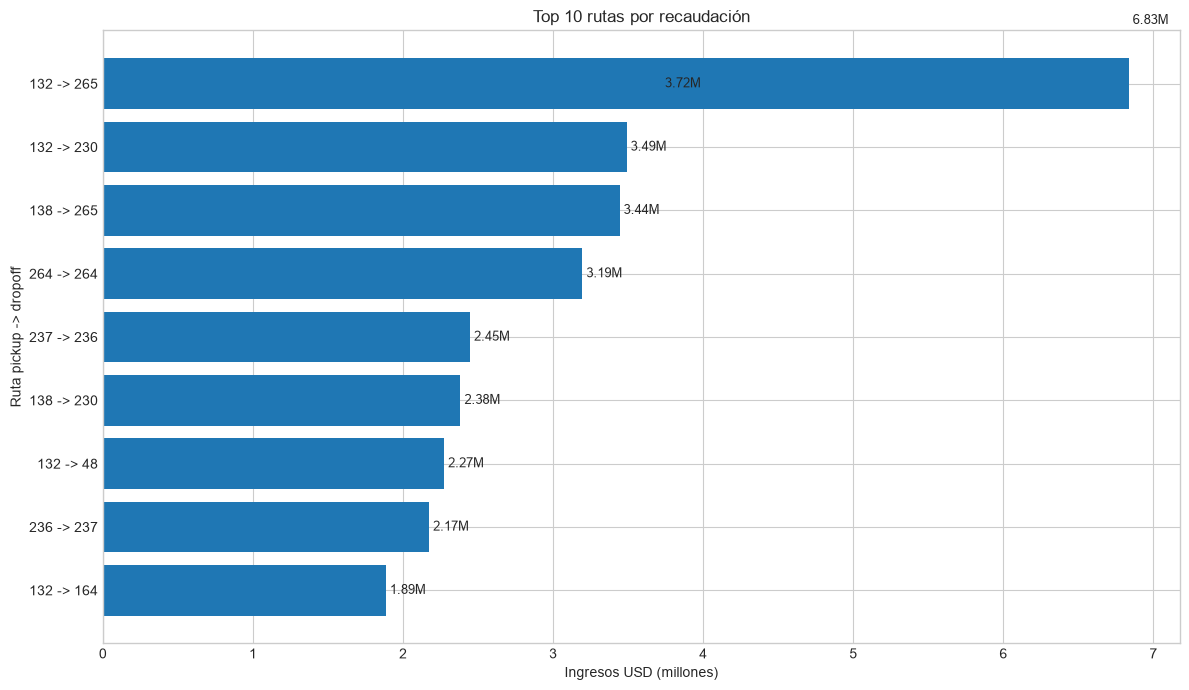

### Top 20 rutas por recaudación

,service_type,pickup_location_id,dropoff_location_id,total_trips,total_revenue,average_fare,average_distance,average_duration,suspicious_trip_count,route
0,fhvhv,132,265,65807,"6,834,994.16",90.79,28.81,49.80,0,132 -> 265
1,yellow,132,265,33701,"3,718,462.84",93.59,21.20,39.04,0,132 -> 265
2,yellow,132,230,40892,"3,489,886.89",64.32,18.22,51.36,0,132 -> 230
3,fhvhv,138,265,35150,"3,443,046.91",84.58,26.29,43.94,0,138 -> 265
4,yellow,264,264,133389,"3,194,786.62",16.99,3.26,14.40,0,264 -> 264
5,yellow,237,236,182404,"2,446,064.54",7.53,1.08,6.80,0,237 -> 236
6,yellow,138,230,36171,"2,382,272.67",42.38,10.34,34.84,0,138 -> 230
7,yellow,132,48,27225,"2,273,204.57",63.42,18.40,51.61,0,132 -> 48
8,yellow,236,237,155290,"2,173,080.01",8.10,1.06,7.95,0,236 -> 237
9,yellow,132,164,21866,"1,885,659.63",64.00,17.42,42.92,0,132 -> 164


In [14]:
top_routes = sql('''
SELECT
    service_type,
    pickup_location_id,
    dropoff_location_id,
    total_trips,
    total_revenue,
    average_fare,
    average_distance,
    average_duration,
    suspicious_trip_count
FROM gold_location_performance
ORDER BY total_revenue DESC
LIMIT 20;
''')

top_routes['route'] = top_routes['pickup_location_id'].astype(str) + ' -> ' + top_routes['dropoff_location_id'].astype(str)

fig, ax = plt.subplots(figsize=(12, 7))
plot_df = top_routes.head(10).sort_values('total_revenue')
ax.barh(plot_df['route'], plot_df['total_revenue'] / 1_000_000, color='#1f77b4')
ax.set_title('Top 10 rutas por recaudación')
ax.set_xlabel('Ingresos USD (millones)')
ax.set_ylabel('Ruta pickup -> dropoff')
for index, value in enumerate(plot_df['total_revenue'] / 1_000_000):
    ax.text(value, index, f' {value:.2f}M', va='center', fontsize=9)
plt.tight_layout()
plt.show()

show_df('Top 20 rutas por recaudación', top_routes)

## 9. Decisiones de optimización Spark

Durante el desarrollo se aplicaron decisiones orientadas a escalabilidad, trazabilidad y estabilidad local:

1. **Esquemas explícitos y casts controlados:** se usaron estructuras y conversiones definidas para evitar depender de inferencias frágiles.
2. **Lectura individual de archivos Parquet:** cada archivo fue auditado de forma independiente para que un archivo corrupto no detenga todo el pipeline.
3. **Lectura selectiva de columnas:** la homologación canónica selecciona solo campos necesarios para el modelo final.
4. **Escritura particionada:** Bronze, Silver y Gold se organizaron por servicio, año, mes o archivo fuente según la capa.
5. **Partition pruning:** las particiones físicas permiten consultas futuras más eficientes por servicio y periodo.
6. **Control de archivos de salida:** se usaron `repartition` y `coalesce` en puntos específicos para evitar fragmentación excesiva.
7. **Corte de linaje en calidad:** la tabla `quality_rejected_records` se persiste antes de reutilizarse para métricas.
8. **Carga SQLite por lotes:** la base se carga desde Spark usando iteración por lotes, sin convertir el procesamiento completo a Pandas.

## 10. Limitaciones identificadas

- La carga a SQLite es válida para demostración académica y consultas locales, pero para producción convendría usar PostgreSQL, Delta Lake, Hive Metastore, Snowflake o BigQuery.
- FHVHV no tiene todos los campos financieros de yellow/green; por eso `total_amount` se reconstruye con la regla documentada `base_passenger_fare + tolls + sales_tax`.
- Los archivos corruptos de Apache Parquet Testing se aíslan correctamente, pero su recuperación completa depende de la naturaleza física del daño.
- La detección de outliers por percentil 99 es una primera aproximación; en producción se recomienda calibrar umbrales por servicio, zona, hora y estacionalidad.
- El entorno local Windows requiere configuración de Hadoop/Winutils para escrituras Spark estables.

## 11. Reflexión crítica

Procesar datos dañados sin auditoría puede producir decisiones equivocadas: ingresos inflados, rutas mal priorizadas, tiempos promedio irreales y pérdida de confianza en la plataforma analítica. Por eso el pipeline separa fallos técnicos de fallos de negocio.

En un ambiente productivo implementaría controles adicionales:

- Validación automática al recibir archivos nuevos.
- Contratos de datos por fuente y versión de esquema.
- Alertas cuando suba el porcentaje de rechazos.
- Monitoreo de drift de distribución en montos, distancias y duración.
- Reprocesamiento idempotente por `process_id`, periodo y fuente.
- Catálogo de datos con linaje desde raw hasta gold.
- Pruebas automatizadas de reglas críticas antes de publicar Gold.

## 12. Conclusiones finales

El proyecto implementa un pipeline ETL avanzado con PySpark sobre archivos Parquet reales de NYC TLC y archivos problemáticos de Apache Parquet Testing. La solución conserva archivos originales en Raw, reconstruye datos recuperables en Bronze, transforma y valida en Silver, publica tablas analíticas en Gold y carga resultados a SQLite.

La evidencia generada demuestra:

- Lectura real de Parquet con auditoría archivo por archivo.
- Detección de archivos corruptos o problemáticos sin detener todo el proceso.
- Homologación de `yellow`, `green` y `fhvhv` bajo un esquema canónico común.
- Separación de registros válidos e inválidos con causas de rechazo trazables.
- Métricas de calidad por servicio, año y mes.
- Tablas Gold listas para análisis de negocio.
- Consultas SQL obligatorias funcionando sobre la base final.

Con esto, el pipeline no solo transforma datos: también deja evidencia técnica suficiente para defender la calidad, reproducibilidad e idempotencia del proceso.

In [15]:
conn.close()
print('Reporte finalizado. Conexión SQLite cerrada correctamente.')

Reporte finalizado. Conexión SQLite cerrada correctamente.
